# Biblioteka Seaborn - Część 1

## Wprowadzenie i podstawowe wykresy

Seaborn to biblioteka zbudowana na Matplotlib, która oferuje piękniejsze wykresy prostszym kodem. Doskonała do statystycznej wizualizacji danych!

## 1. Wprowadzenie do Seaborn

**Seaborn** to wysokopoziomowa biblioteka do wizualizacji danych, zbudowana na Matplotlib.

### Czym różni się od Matplotlib?

| Cecha | Matplotlib | Seaborn |
|-------|-----------|----------|
| **Kod** | Długi, szczegółowy | Krótki, zwięzły |
| **Estetyka** | Podstawowa | Piękna domyślnie |
| **Integracja z Pandas** | Dobra | Doskonała |
| **Wykresy statystyczne** | Podstawowe | Zaawansowane |
| **Kontrola** | Pełna | Średnia |

### Kiedy używać Seaborn?

✅ **Używaj Seaborn gdy:**
- Chcesz szybko stworzyć ładny wykres
- Analizujesz dane statystycznie
- Pracujesz z Pandas DataFrame
- Potrzebujesz wykresów jak boxplot, violinplot, heatmap

❌ **Zostań przy Matplotlib gdy:**
- Potrzebujesz pełnej kontroli nad każdym pixelem
- Tworzysz niestandardowe, złożone wizualizacje
- Seaborn nie ma typu wykresu którego potrzebujesz

### Zalety Seaborn:

1. **Piękne domyślne style** - wykresy wyglądają profesjonalnie bez dostosowywania
2. **Mniej kodu** - to samo co Matplotlib w 2-3 liniach zamiast 10
3. **Wbudowane funkcje statystyczne** - automatyczne przedziały ufności, regresje
4. **Świetna integracja z Pandas** - bezpośrednio używasz nazw kolumn
5. **Palety kolorów** - profesjonalne, przemyślane palety

### Import i setup

In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

# Ustaw styl Seaborn
sns.set_theme()  # To zmienia domyślny styl Matplotlib!

print(f"Seaborn version: {sns.__version__}")
print("Seaborn zaimportowany pomyślnie!")

Seaborn version: 0.13.2
Seaborn zaimportowany pomyślnie!


### Wczytanie danych

In [3]:
# Wczytaj nasze dane
df_prac = pd.read_csv('../data/pracownicy.csv')
df_pogoda = pd.read_csv('../data/pogoda.csv')
df_sprzedaz = pd.read_csv('../data/sprzedaz.csv')
df_sprzedaz['data'] = pd.to_datetime(df_sprzedaz['data'])
df_sprzedaz['wartosc_sprzedazy'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

print("Dane wczytane pomyślnie!")
print(f"Pracownicy: {len(df_prac)} wierszy")
print(f"Pogoda: {len(df_pogoda)} wierszy")
print(f"Sprzedaż: {len(df_sprzedaz)} wierszy")

Dane wczytane pomyślnie!
Pracownicy: 50 wierszy
Pogoda: 170 wierszy
Sprzedaż: 123 wierszy


### Pierwszy wykres - porównanie Matplotlib vs Seaborn

Zobaczmy różnicę!

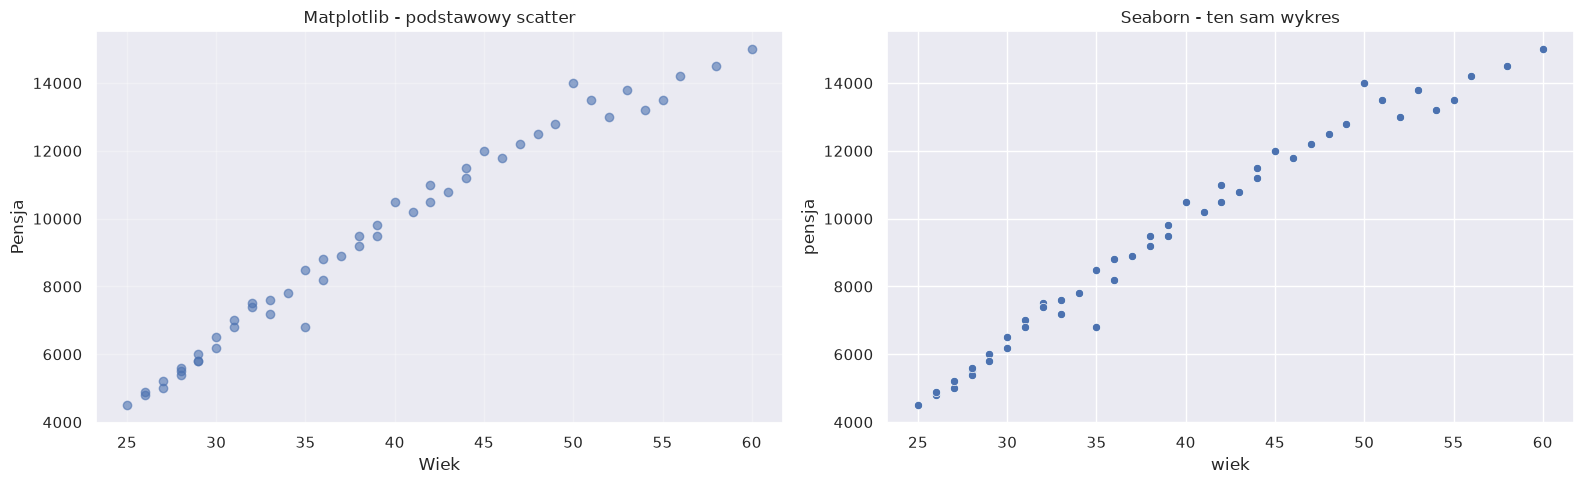

Zauważ:
- Seaborn: 1 linia kodu
- Matplotlib: 5 linii kodu
- Seaborn wygląda lepiej domyślnie!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MATPLOTLIB - dużo kodu
axes[0].scatter(df_prac['wiek'], df_prac['pensja'], alpha=0.6)
axes[0].set_title('Matplotlib - podstawowy scatter', fontsize=12)
axes[0].set_xlabel('Wiek')
axes[0].set_ylabel('Pensja')
axes[0].grid(True, alpha=0.3)

# SEABORN - krótki kod, piękny efekt
sns.scatterplot(data=df_prac, x='wiek', y='pensja', ax=axes[1])
axes[1].set_title('Seaborn - ten sam wykres', fontsize=12)

plt.tight_layout()
plt.show()

print("Zauważ:")
print("- Seaborn: 1 linia kodu")
print("- Matplotlib: 5 linii kodu")
print("- Seaborn wygląda lepiej domyślnie!")

## 2. Wykresy relacji (Relationship plots)

Wykresy relacji pokazują zależności między zmiennymi.

### 2.1 Scatter plot (`scatterplot`)

W Seaborn scatter plot jest o wiele potężniejszy!

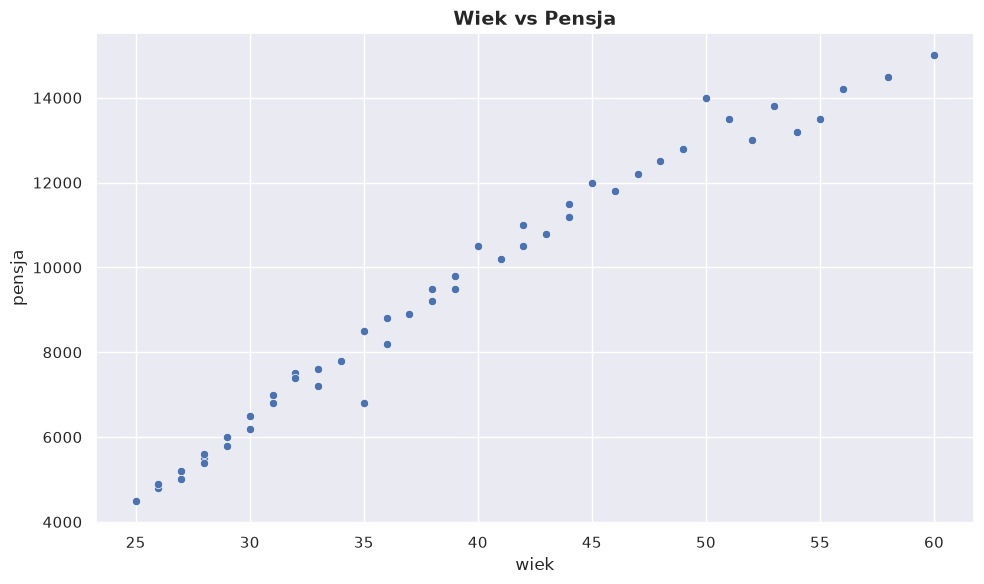

In [5]:
# Prosty scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_prac, x='wiek', y='pensja')

plt.title('Wiek vs Pensja', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Scatter plot z kolorowaniem według kategorii (`hue`)

**`hue`** - automatycznie koloruje według kategorii!

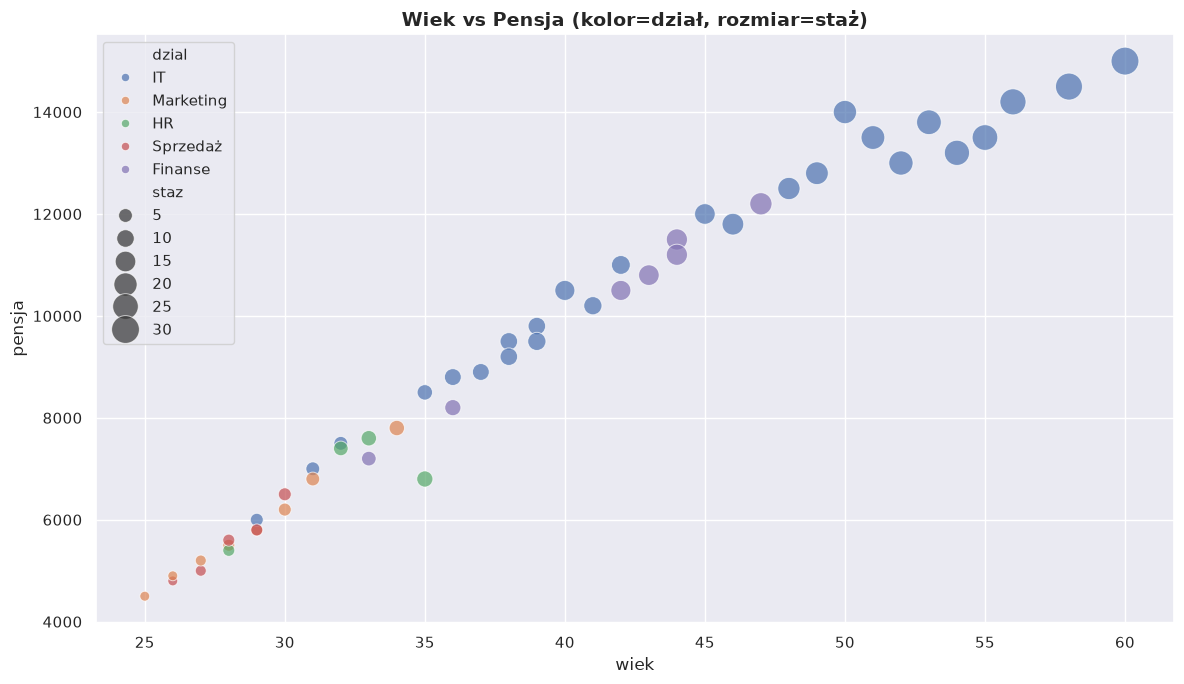

In [6]:
# Scatter z kolorowaniem według działu
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df_prac, 
                x='wiek', 
                y='pensja',
                hue='dzial',        # Koloruj według działu!
                size='staz',        # Rozmiar według stażu
                sizes=(50, 400),    # Min i max rozmiar
                alpha=0.7)

plt.title('Wiek vs Pensja (kolor=dział, rozmiar=staż)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Zauważ:** Seaborn automatycznie:
- Wybrał kolory dla każdego działu
- Dodał legendę
- Dostosował rozmiary punktów

To samo w Matplotlib wymagałoby ~20 linii kodu!

### 2.2 Line plot (`lineplot`)

Line plot z **automatyczną agregacją i przedziałami ufności!**

**⚡ MAGIA Seaborn:**
- Jeśli dla tego samego `x` masz wiele wartości `y` → seaborn **automatycznie** obliczy średnią i przedział ufności
- Jeśli dla każdego `x` jest tylko jedno `y` → po prostu połączy punkty linią

**Przykład:** Dla każdego miesiąca mamy 28-31 pomiarów temperatury (po jednym dziennie). Seaborn automatycznie:
1. Obliczy średnią temperaturę dla każdego miesiąca
2. Obliczy 95% przedział ufności
3. Narysuje linię przez średnie + zacieniowany obszar (CI)

🔍 **Chcesz szczegółów?** Zobacz [03_seaborn_FAQ.md](03_seaborn_FAQ.md#1--jak-działa-automatyczna-agregacja-w-lineplot) - wyjaśnienie mechanizmu agregacji krok po kroku.

📊 Co seaborn zrobi automatycznie:
   Dla każdego miesiąca (1-12) obliczy średnią z wielu pomiarów
   Przykład: styczeń ma 20 pomiarów
   → seaborn obliczy średnią + przedział ufności

💡 Zobacz 03_seaborn_FAQ.md dla szczegółów!



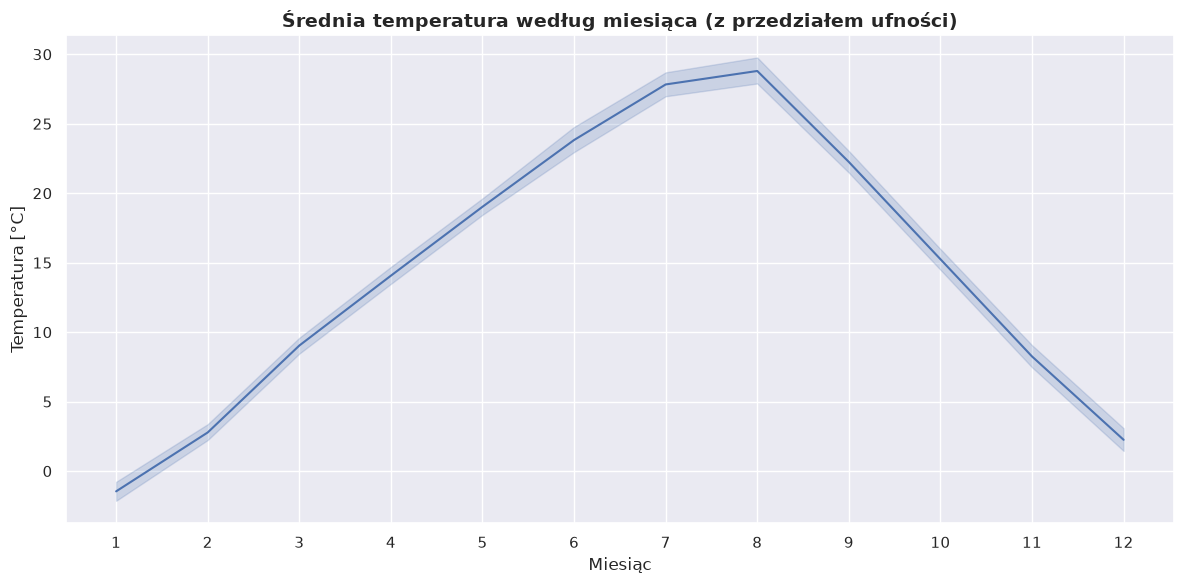

In [7]:
# Przygotuj dane - średnia temperatura według miesiąca
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])
df_pogoda['miesiac'] = df_pogoda['data'].dt.month

print("📊 Co seaborn zrobi automatycznie:")
print(f"   Dla każdego miesiąca (1-12) obliczy średnią z wielu pomiarów")
print(f"   Przykład: styczeń ma {len(df_pogoda[df_pogoda['miesiac']==1])} pomiarów")
print(f"   → seaborn obliczy średnią + przedział ufności")
print("\n💡 Zobacz 03_seaborn_FAQ.md dla szczegółów!\n")

plt.figure(figsize=(12, 6))

# Seaborn automatycznie policzy średnią i przedział ufności!
sns.lineplot(data=df_pogoda, x='miesiac', y='temperatura')

plt.title('Średnia temperatura według miesiąca (z przedziałem ufności)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Miesiąc')
plt.ylabel('Temperatura [°C]')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Seaborn automatycznie:
- Obliczył średnią temperaturę dla każdego miesiąca
- Dodał przedział ufności (zacieniowany obszar)
- Narysował ładny wykres

Wszystko w 1 linii kodu!

### Line plot z grupowaniem (`hue`)

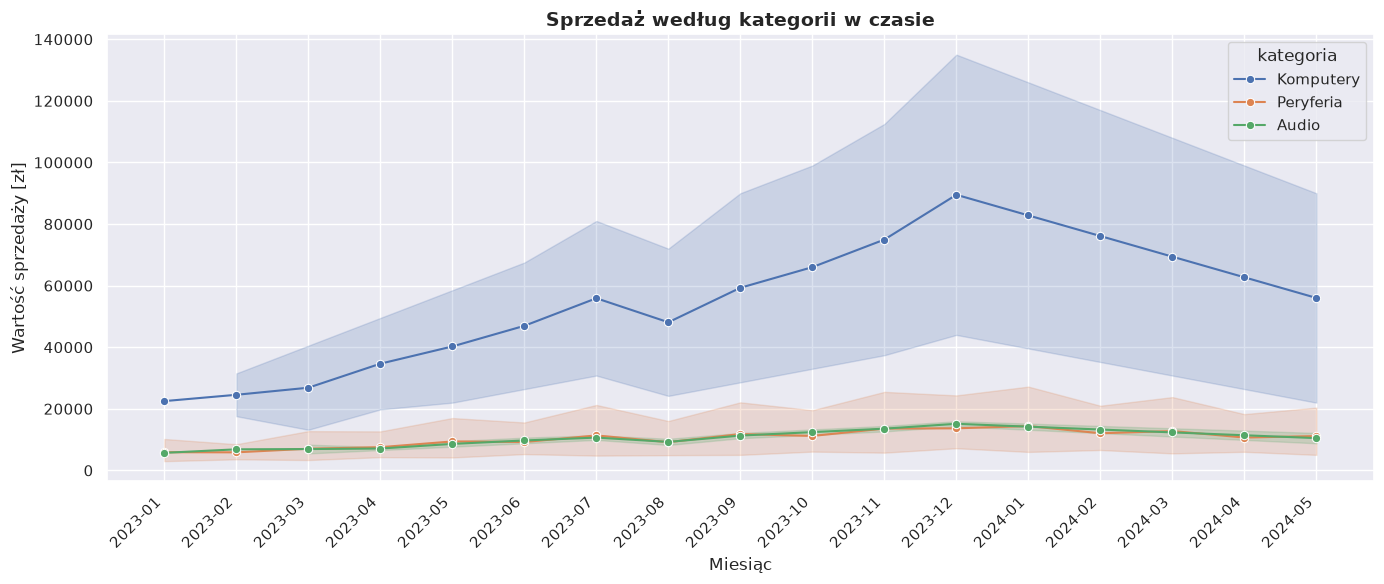

In [8]:
# Sprzedaż według kategorii w czasie
df_sprzedaz['miesiac'] = df_sprzedaz['data'].dt.to_period('M').astype(str)

plt.figure(figsize=(14, 6))

sns.lineplot(data=df_sprzedaz, 
             x='miesiac', 
             y='wartosc_sprzedazy',
             hue='kategoria',        # Osobna linia dla każdej kategorii
             marker='o')

plt.title('Sprzedaż według kategorii w czasie', fontsize=14, fontweight='bold')
plt.xlabel('Miesiąc')
plt.ylabel('Wartość sprzedaży [zł]')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.3 Relplot - wykresy relacji z facetami (ang. facets)

`relplot` to uniwersalna funkcja dla wykresów relacji, która dodatkowo pozwala na **faceting** (podział na panele).

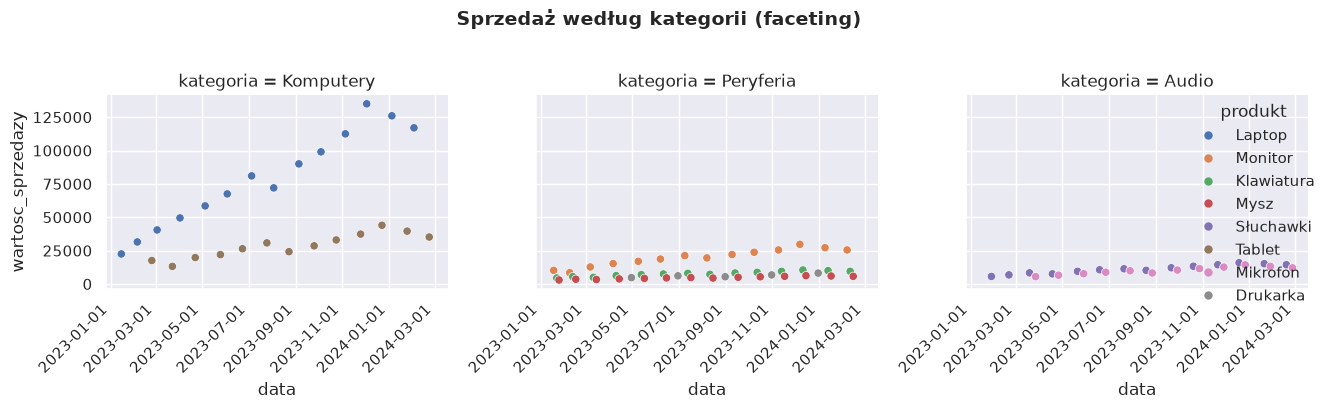

In [9]:
# Relplot z facetami - osobny panel dla każdej kategorii
g = sns.relplot(data=df_sprzedaz.head(100),
                x='data',
                y='wartosc_sprzedazy',
                hue='produkt',
                col='kategoria',        # Osobna kolumna dla każdej kategorii
                kind='scatter',         # 'scatter' lub 'line'
                col_wrap=3,             # Max 3 kolumny
                height=4)

g.fig.suptitle('Sprzedaż według kategorii (faceting)', fontsize=14, fontweight='bold', y=1.02)

# Obróć etykiety na osi X
g.set_xticklabels(rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## Ćwiczenie 3.1 (w trakcie) - Scatter plot z hue

**Cel:** Stworzyć scatter plot z kolorowaniem.

**Zadanie:**
1. Użyj danych pracowników
2. Utwórz scatter plot: staż (x) vs pensja (y)
3. Użyj `hue='dzial'` do kolorowania według działu
4. Dodaj tytuł
5. Przeanalizuj: czy w każdym dziale dłuższy staż = wyższa pensja?

**Czas:** 10 minut

In [10]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df_prac,
                x='staz',
                y='pensja',
                hue='dzial',
                s=100,
                alpha=0.7)

plt.title('Staż vs Pensja według działów', fontsize=14, fontweight='bold')
plt.xlabel('Staż [lata]', fontsize=12)
plt.ylabel('Pensja [zł]', fontsize=12)
plt.tight_layout()
plt.show()

# Analiza
print("Analiza korelacji staż-pensja według działów:")
for dzial in df_prac['dzial'].unique():
    dane_dzialu = df_prac[df_prac['dzial'] == dzial]
    corr = dane_dzialu['staz'].corr(dane_dzialu['pensja'])
    print(f"{dzial:12s}: korelacja = {corr:.3f}")
```

</details>

---
## 3. Wykresy rozkładów (Distribution plots)

Wykresy rozkładów pokazują jak wartości są rozproszone.

### 3.1 Histogram (`histplot`)

Histogram w Seaborn jest bardziej elastyczny niż w Matplotlib.

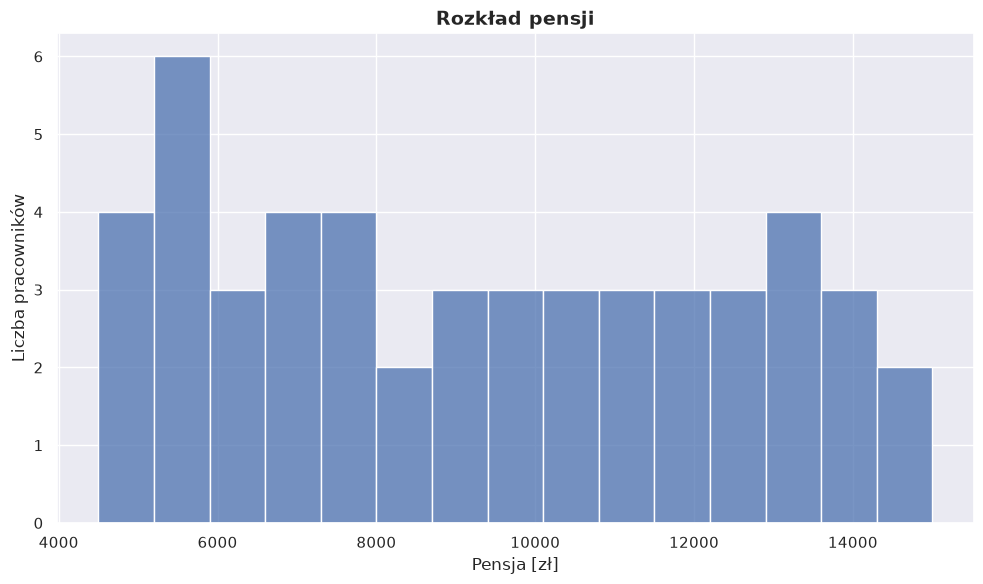

In [11]:
# Prosty histogram
plt.figure(figsize=(10, 6))

sns.histplot(data=df_prac, x='pensja', bins=15)

plt.title('Rozkład pensji', fontsize=14, fontweight='bold')
plt.xlabel('Pensja [zł]')
plt.ylabel('Liczba pracowników')
plt.tight_layout()
plt.show()

### Histogram z KDE (Kernel Density Estimate)

KDE to wygładzona wersja histogramu.

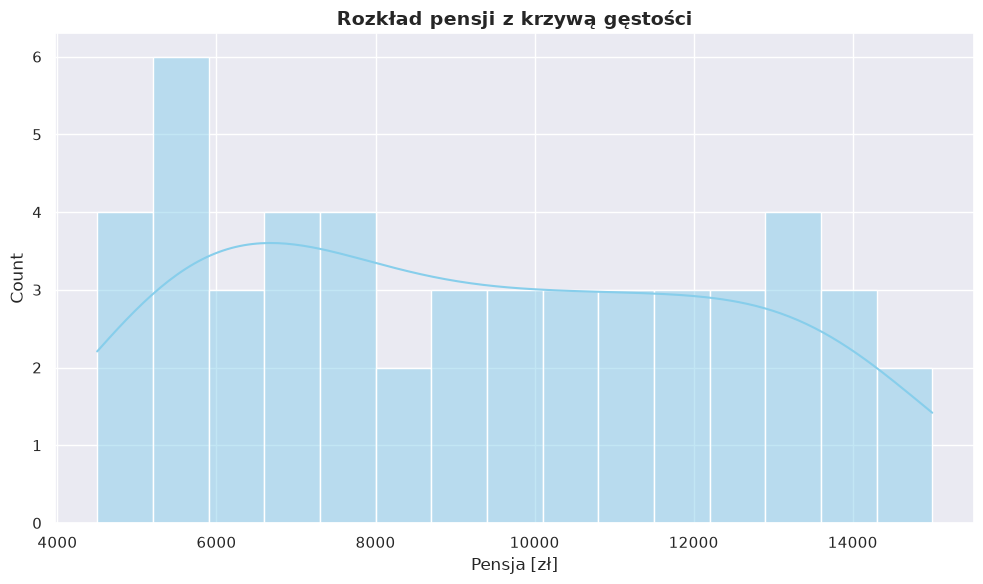

In [12]:
# Histogram + KDE
plt.figure(figsize=(10, 6))

sns.histplot(data=df_prac, 
             x='pensja', 
             bins=15, 
             kde=True,          # Dodaj krzywą gęstości
             color='skyblue')

plt.title('Rozkład pensji z krzywą gęstości', fontsize=14, fontweight='bold')
plt.xlabel('Pensja [zł]')
plt.tight_layout()
plt.show()

### Histogram z grupowaniem według kategorii

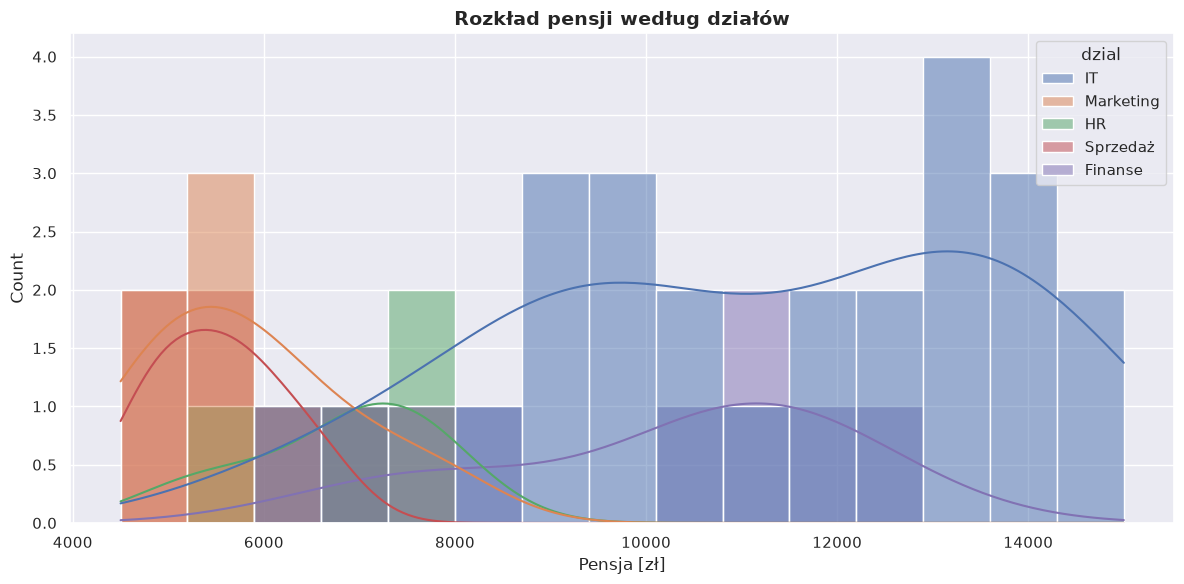

In [13]:
# Histogram z hue - rozkład pensji według działów
plt.figure(figsize=(12, 6))

sns.histplot(data=df_prac,
             x='pensja',
             hue='dzial',       # Osobny kolor dla każdego działu
             bins=15,
             kde=True,
             alpha=0.5)         # Przezroczystość ważna przy nakładaniu

plt.title('Rozkład pensji według działów', fontsize=14, fontweight='bold')
plt.xlabel('Pensja [zł]')
plt.tight_layout()
plt.show()

### 3.2 KDE plot (`kdeplot`)

Tylko krzywa gęstości, bez histogramu.

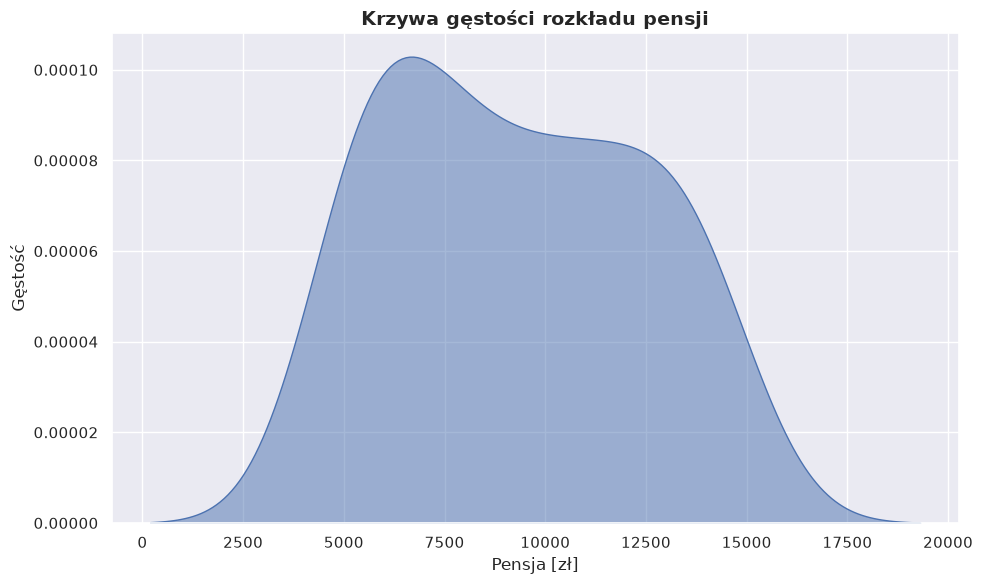

In [14]:
# KDE plot
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_prac, x='pensja', fill=True, alpha=0.5)

plt.title('Krzywa gęstości rozkładu pensji', fontsize=14, fontweight='bold')
plt.xlabel('Pensja [zł]')
plt.ylabel('Gęstość')
plt.tight_layout()
plt.show()

### KDE 2D - rozkład dwóch zmiennych

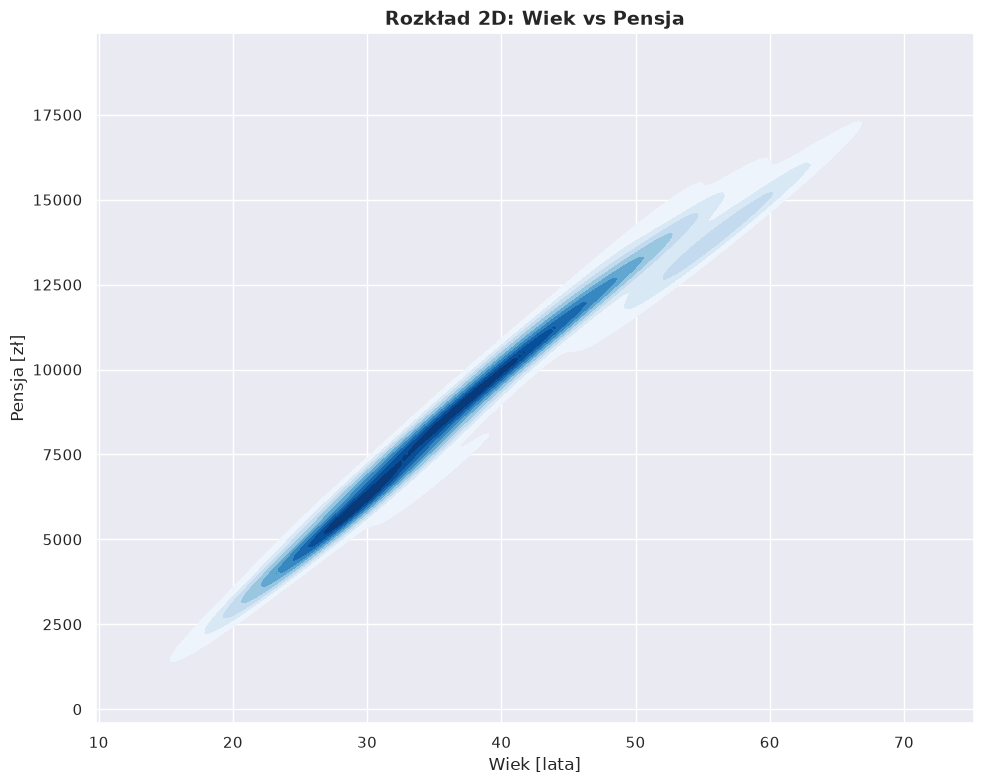

In [15]:
# 2D KDE - wiek vs pensja
plt.figure(figsize=(10, 8))

sns.kdeplot(data=df_prac,
            x='wiek',
            y='pensja',
            fill=True,          # Wypełnienie
            cmap='Blues',       # Paleta kolorów
            levels=10)          # Liczba konturów

plt.title('Rozkład 2D: Wiek vs Pensja', fontsize=14, fontweight='bold')
plt.xlabel('Wiek [lata]')
plt.ylabel('Pensja [zł]')
plt.tight_layout()
plt.show()

### 3.3 Box plot (`boxplot`)

Box plot pokazuje medianę, kwartyle i wartości odstające.

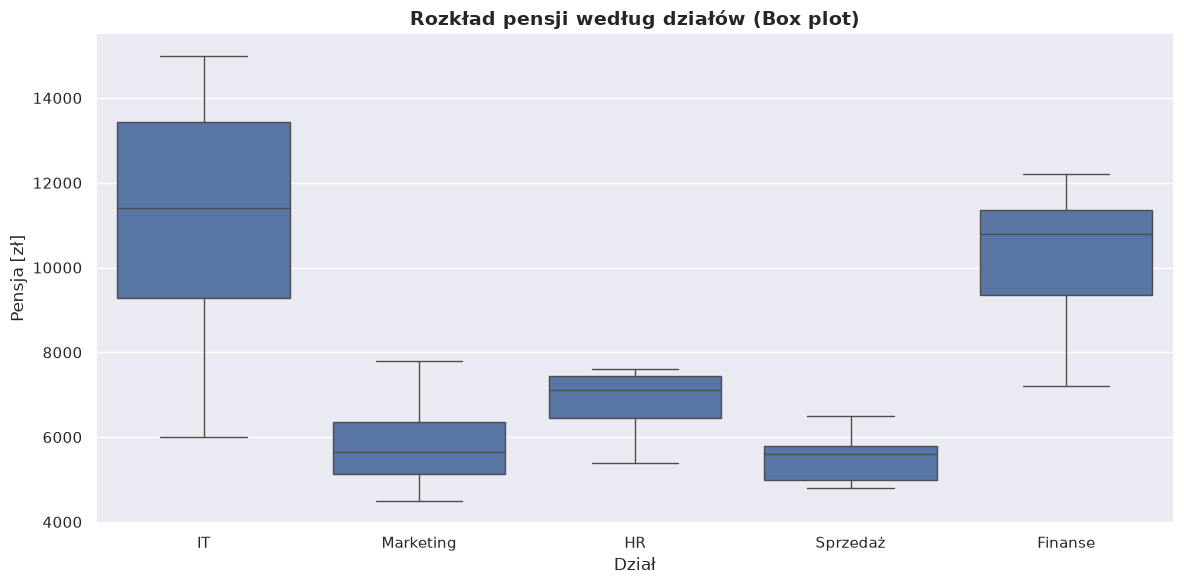

Elementy box plota:
- Linia środkowa: mediana (50% wartości poniżej/powyżej)
- Pudełko: Q1 (25%) do Q3 (75%) - gdzie jest 50% danych
- Wąsy: 1.5 × IQR (Inter Quartile Range)
- Punkty: wartości odstające (outliers)


In [16]:
# Box plot - pensje według działów
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_prac, x='dzial', y='pensja')

plt.title('Rozkład pensji według działów (Box plot)', fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Pensja [zł]')
plt.tight_layout()
plt.show()

print("Elementy box plota:")
print("- Linia środkowa: mediana (50% wartości poniżej/powyżej)")
print("- Pudełko: Q1 (25%) do Q3 (75%) - gdzie jest 50% danych")
print("- Wąsy: 1.5 × IQR (Inter Quartile Range)")
print("- Punkty: wartości odstające (outliers)")

### 3.4 Violin plot (`violinplot`)

Violin plot = Box plot + KDE. Pokazuje pełny rozkład!

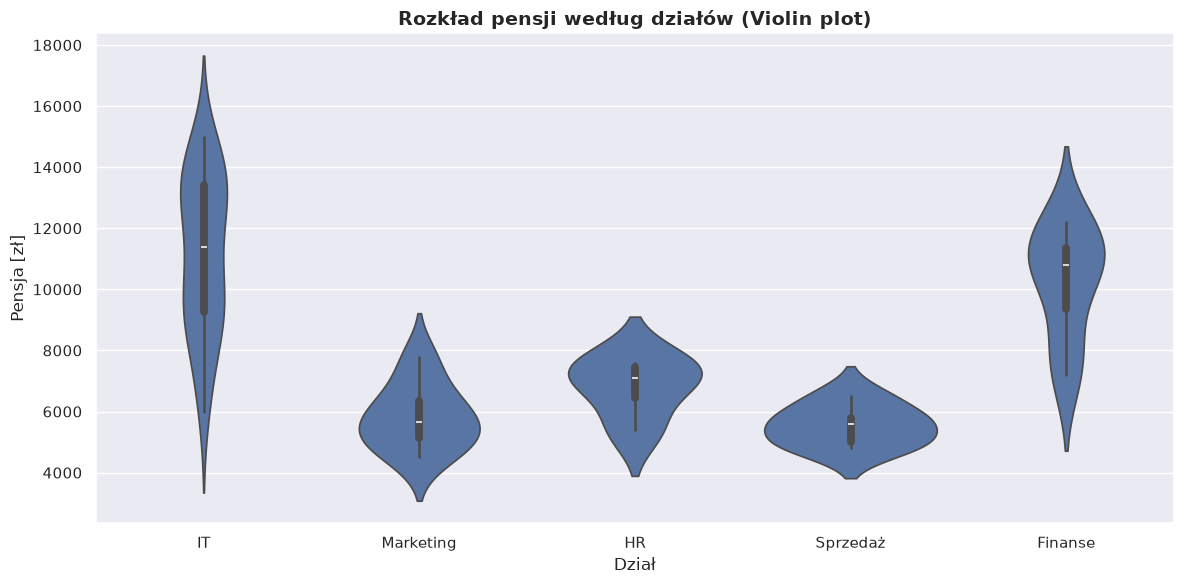

Violin plot pokazuje:
- Szerokość = gęstość (ile obserwacji w danym miejscu)
- Kształt = rozkład wartości
- Wewnętrzne białe pudełko = jak w box plot


In [17]:
# Violin plot
plt.figure(figsize=(12, 6))

sns.violinplot(data=df_prac, x='dzial', y='pensja')

plt.title('Rozkład pensji według działów (Violin plot)', fontsize=14, fontweight='bold')
plt.xlabel('Dział')
plt.ylabel('Pensja [zł]')
plt.tight_layout()
plt.show()

print("Violin plot pokazuje:")
print("- Szerokość = gęstość (ile obserwacji w danym miejscu)")
print("- Kształt = rozkład wartości")
print("- Wewnętrzne białe pudełko = jak w box plot")

### Box plot vs Violin plot - porównanie

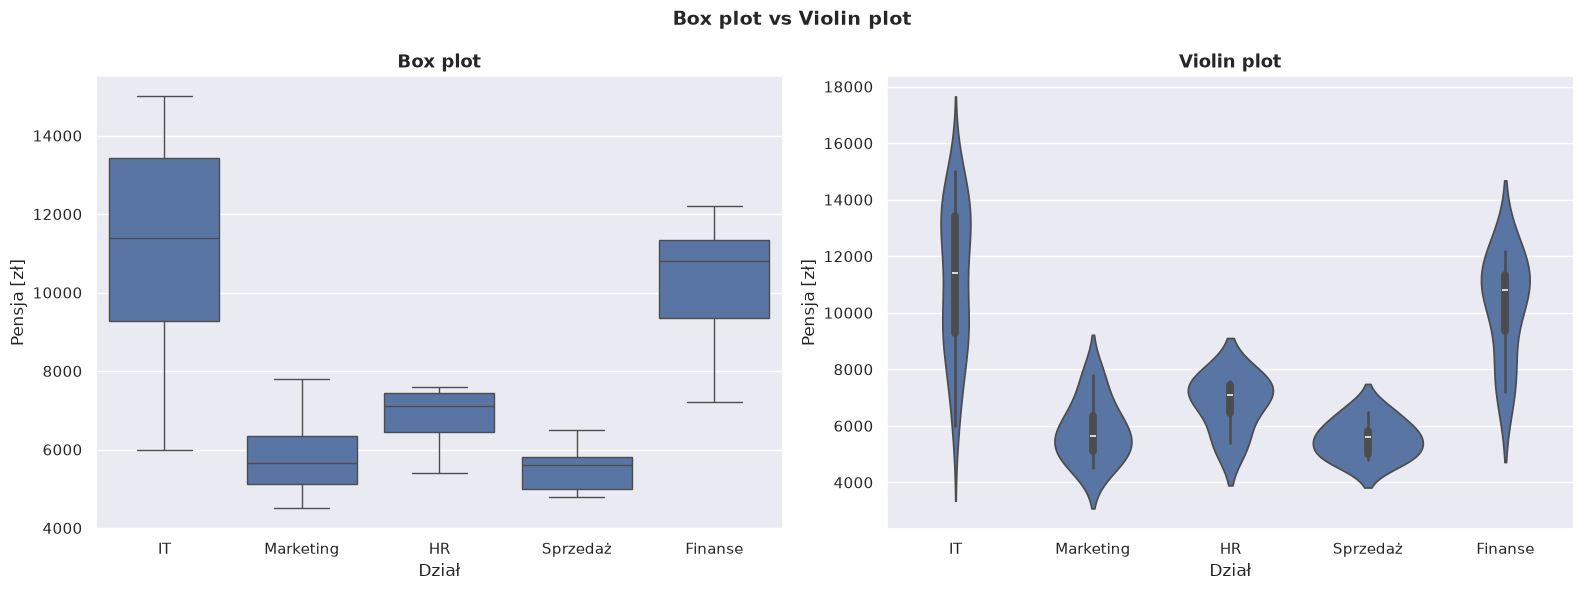

Kiedy którego użyć:
- Box plot: szybki przegląd, wartości odstające
- Violin plot: szczegółowy rozkład, wykrywanie wzorców (np. bimodalność)


In [18]:
# Porównanie obok siebie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df_prac, x='dzial', y='pensja', ax=axes[0])
axes[0].set_title('Box plot', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dział')
axes[0].set_ylabel('Pensja [zł]')

# Violin plot
sns.violinplot(data=df_prac, x='dzial', y='pensja', ax=axes[1])
axes[1].set_title('Violin plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dział')
axes[1].set_ylabel('Pensja [zł]')

plt.suptitle('Box plot vs Violin plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Kiedy którego użyć:")
print("- Box plot: szybki przegląd, wartości odstające")
print("- Violin plot: szczegółowy rozkład, wykrywanie wzorców (np. bimodalność)")

---
## Ćwiczenie 3.3 (w trakcie) - Box plot porównujący grupy

**Cel:** Porównać rozkład wieku w różnych działach.

**Zadanie:**
1. Użyj danych pracowników
2. Utwórz box plot pokazujący wiek (y) według działu (x)
3. Dodaj tytuł i opisy osi
4. Odpowiedz:
   - Który dział ma najstarszych pracowników?
   - Który dział ma największy rozrzut wieku?
   - Czy są wartości odstające?

**Czas:** 10 minut

In [19]:
# TWÓJ KOD TUTAJ


<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_prac, x='dzial', y='wiek')

plt.title('Rozkład wieku według działów', fontsize=14, fontweight='bold')
plt.xlabel('Dział', fontsize=12)
plt.ylabel('Wiek [lata]', fontsize=12)
plt.tight_layout()
plt.show()

# Analiza statystyczna
print("Statystyki wieku według działów:\n")
print(df_prac.groupby('dzial')['wiek'].describe())

print("\nOdpowiedzi:")
mediany = df_prac.groupby('dzial')['wiek'].median()
print(f"1. Najstarsi pracownicy: {mediany.idxmax()} (mediana: {mediany.max():.1f} lat)")

std_dev = df_prac.groupby('dzial')['wiek'].std()
print(f"2. Największy rozrzut: {std_dev.idxmax()} (std: {std_dev.max():.1f})")

print("3. Wartości odstające: sprawdź na wykresie (punkty poza wąsami)")
```

</details>

---
## Ćwiczenie 3.4 (do domu) - Violin plot vs Box plot

**Cel:** Porównać violin plot i box plot dla tego samego zbioru danych.

**Zadanie:**
1. Utwórz figurę z dwoma wykresami obok siebie
2. Lewy: box plot stażu według działów
3. Prawy: violin plot stażu według działów
4. Porównaj oba wykresy - co widać lepiej na violin plot?
5. Napisz wnioski w komentarzu

**Czas:** 20 minut

In [20]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df_prac, x='dzial', y='staz', ax=axes[0])
axes[0].set_title('Box plot - Staż według działów', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dział', fontsize=11)
axes[0].set_ylabel('Staż [lata]', fontsize=11)

# Violin plot
sns.violinplot(data=df_prac, x='dzial', y='staz', ax=axes[1])
axes[1].set_title('Violin plot - Staż według działów', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dział', fontsize=11)
axes[1].set_ylabel('Staż [lata]', fontsize=11)

plt.suptitle('Porównanie: Box plot vs Violin plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Wnioski
print("="*60)
print("WNIOSKI - Co widać lepiej na violin plot:")
print("="*60)
print("1. ROZKŁAD - violin plot pokazuje pełny kształt rozkładu")
print("   Box plot: tylko kwartyle")
print("   Violin: widzimy czy rozkład jest równomierny czy ma 'szczyty'")
print("\n2. BIMODALNOŚĆ - violin wykryje dwa szczyty w danych")
print("   Przykład: jeśli dział ma juniorów i seniorów, violin to pokaże")
print("\n3. GĘSTOŚĆ - szerokość violin = ile obserwacji w danym miejscu")
print("   Box plot: tego nie pokazuje")
print("\n4. SYMETRIA - łatwo zobaczyć czy rozkład jest symetryczny")
print("\nKIEDY KTÓREGO UŻYĆ:")
print("- Box plot: szybki przegląd, porównanie median, wartości odstające")
print("- Violin plot: szczegółowa analiza rozkładu, wykrywanie wzorców")
```

</details>

---
## Podsumowanie - Część 1

W tej części nauczyłeś się:

✅ Czym jest Seaborn i dlaczego jest lepszy od Matplotlib  
✅ Wykresów relacji (`scatterplot`, `lineplot`, `relplot`)  
✅ Magicznego parametru `hue` do kolorowania  
✅ Wykresów rozkładów (`histplot`, `kdeplot`, `boxplot`, `violinplot`)  
✅ Facetingu (podział na panele)  

### Kluczowe wnioski:

1. **Seaborn = mniej kodu, lepszy efekt**
2. **`hue`** - używaj do kolorowania według kategorii
3. **Box plot** - szybki przegląd statystyk
4. **Violin plot** - szczegółowy rozkład
5. **Seaborn automatycznie dodaje przedziały ufności**

### Co dalej?

W **Części 2** nauczysz się:
- Wykresów kategorycznych (`barplot`, `countplot`, `catplot`)
- Heatmap i macierzy korelacji
- Pairplot - wszystkie zmienne naraz
- Stylowania w Seaborn
- Różnic między Matplotlib i Seaborn

**Gotowy na więcej? Przejdź do Part 2!** 🚀